## Step 4 — Train YOLOv8 on the VLM-generated labels

We fine-tune `yolov8n.pt` on the 40-image training set that the VLM labeled in notebook 02. The point isn't state-of-the-art accuracy — it's to prove that VLM-generated annotations are good enough to train a real, small, fast detector that we can then deploy on the edge or on RHOAI.

**Input:** `datasets/vlm-annotated/dataset.yaml` from notebook 03.  
**Output:** `best.pt` (training weights) and `best.onnx` (for serving via OpenVINO). Both consumed by [`05-register-and-deploy.ipynb`](05-register-and-deploy.ipynb).

In [1]:
%%capture
!pip install ultralytics torch torchvision

In [ ]:
from pathlib import Path

import torch
from ultralytics import YOLO

DATA_YAML = Path("datasets/vlm-annotated/dataset.yaml").resolve()
RUN_NAME  = "ppe-vlm"

assert DATA_YAML.is_file(), f"Missing {DATA_YAML} — run notebook 03 first."
print("CUDA available:", torch.cuda.is_available())

## Train

100 epochs × 40 images × frozen backbone takes ~8–12 min on a single GPU, ~30–40 min on CPU. The hyperparameters are tuned for tiny-dataset stability — see the inline comments.

Ultralytics 8.4.41 🚀 Python-3.13.12 torch-2.11.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/datasets/vlm-annotated/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe-vlm, nbs=64, nms=False, opset=None, optimize=False, optimizer

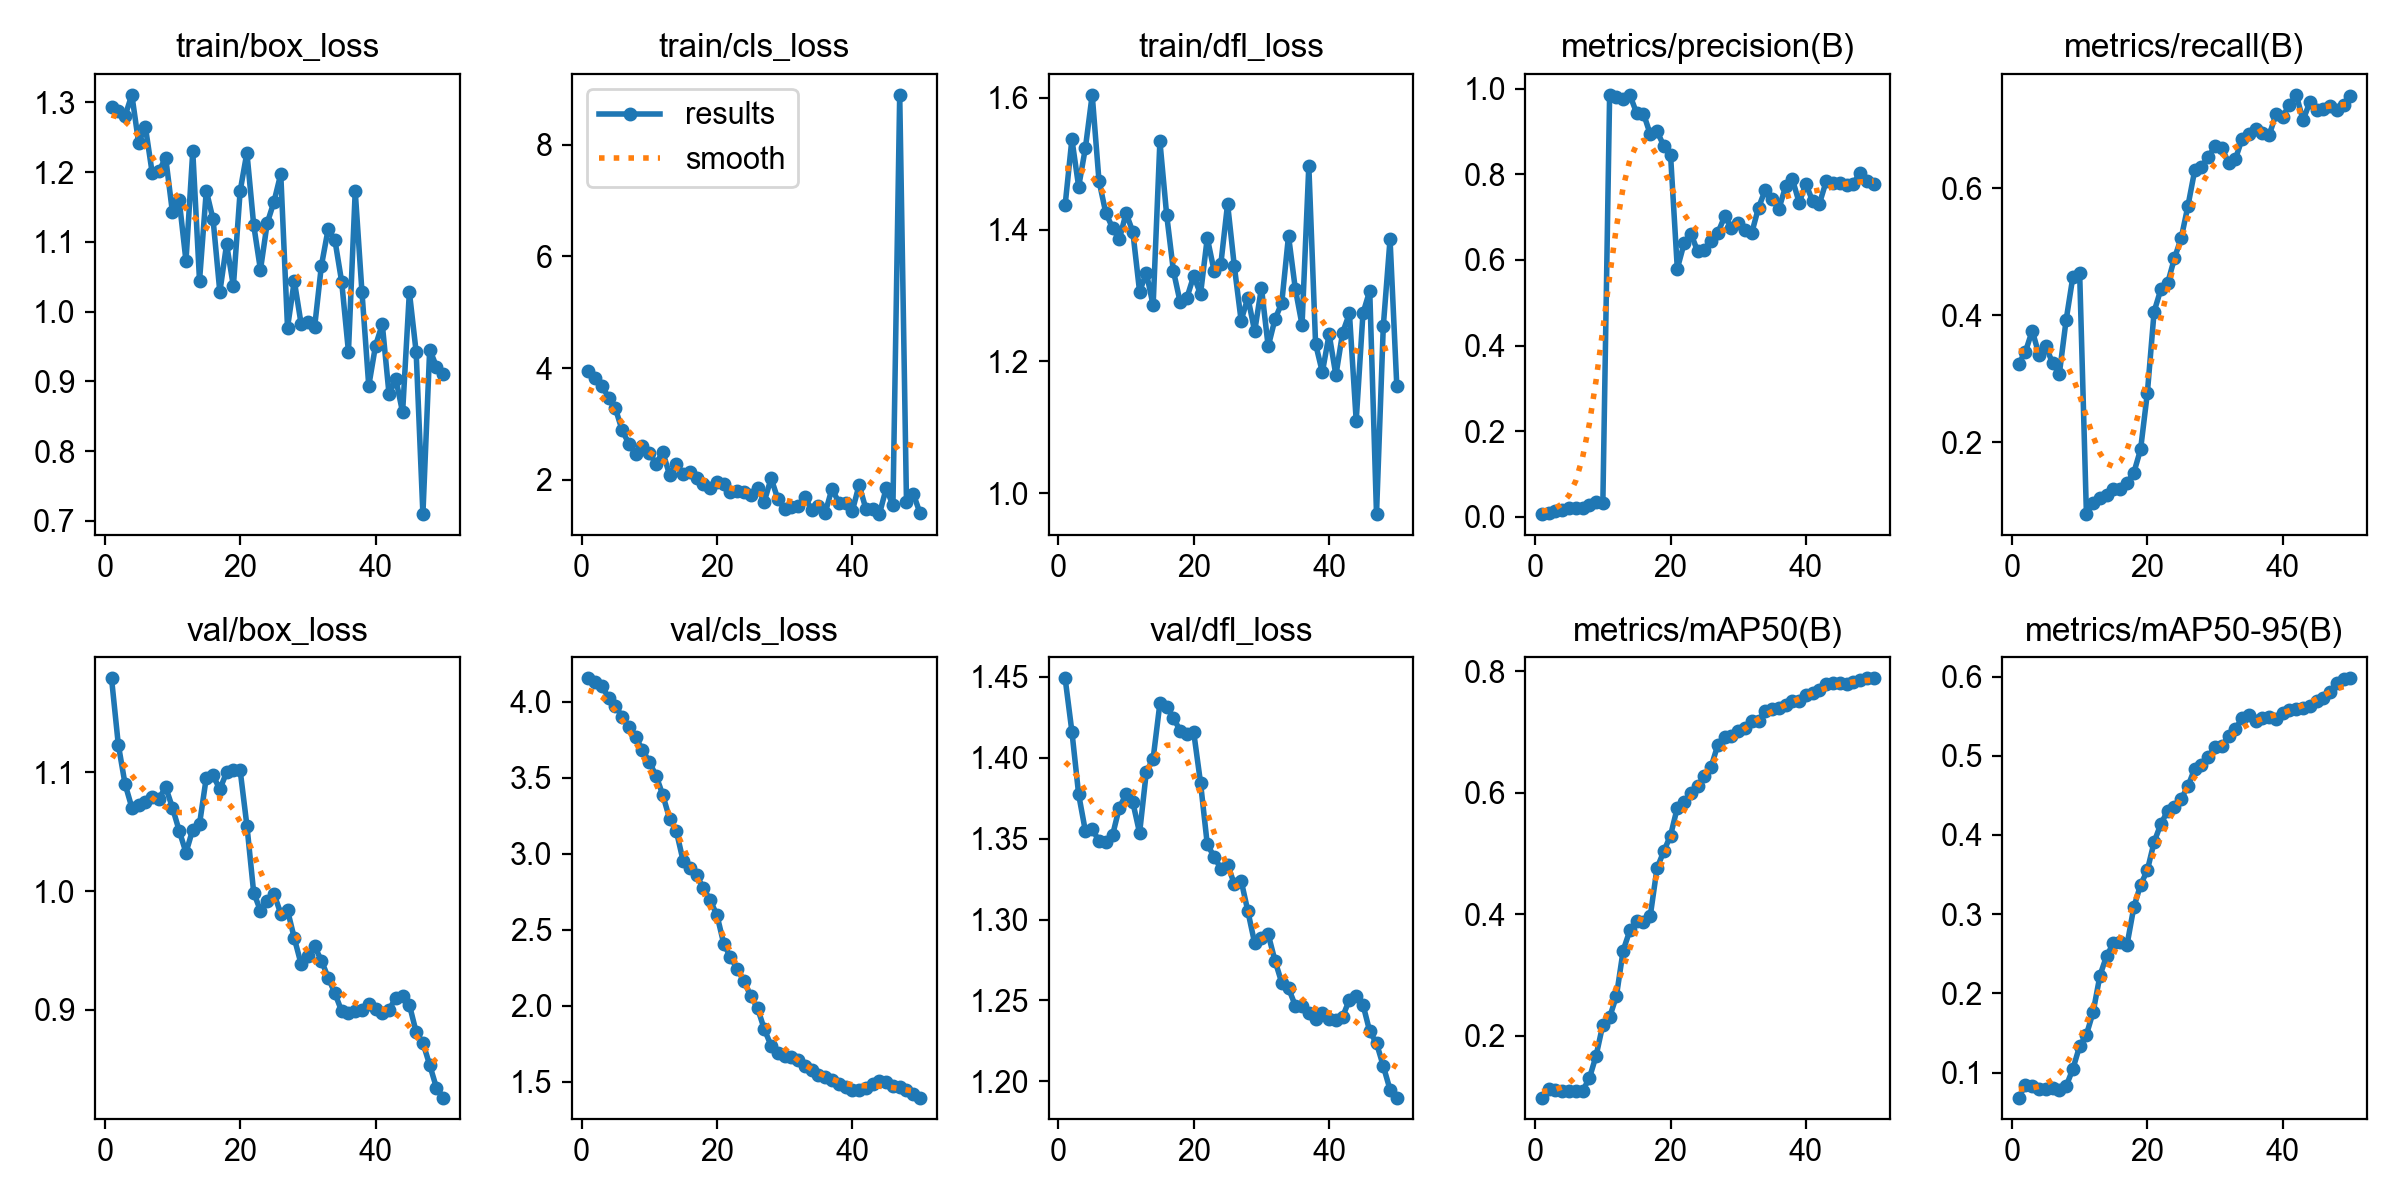

In [12]:
from IPython.display import Image as IPyImage, display

model = YOLO("yolov8n.pt")

# Tuned for a tiny (40-image) training set:
#   epochs=100      — 20 was barely enough to warm up; 100 gives the head time to fit.
#   lr0=0.001       — YOLO's default 0.01 is too aggressive and drives the model
#                     toward under-confident predictions on small data.
#   freeze=10       — freeze the backbone, fine-tune only the detection head.
#                     Classic small-data trick: prevents the pretrained backbone
#                     features from being destroyed by the tiny dataset.
#   patience=20     — allow plateaus before early-stopping.
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.001,
    freeze=10,
    patience=20,
    name=RUN_NAME,
    exist_ok=True,
)

# Ultralytics decides where artifacts land based on its settings.json (runs_dir).
# Grab the actual save directory it used so we don't have to guess the path.
SAVE_DIR = Path(model.trainer.save_dir)
print(f"\nTraining artifacts: {SAVE_DIR}")

# Inline the final loss/mAP curves so the workshop audience can see the trajectory.
results_png = SAVE_DIR / "results.png"
if results_png.is_file():
    display(IPyImage(str(results_png)))

## Quick evaluation

In [13]:
best_pt = SAVE_DIR / "weights" / "best.pt"
print(f"Best weights: {best_pt}")

trained = YOLO(str(best_pt))
metrics = trained.val(data=str(DATA_YAML), imgsz=640)
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Best weights: /Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/runs/detect/ppe-vlm/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.13.12 torch-2.11.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 307.8±159.6 MB/s, size: 69.9 KB)
val: Scanning /Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/datasets/vlm-annotated/labels/train.cache... 39 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 26.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5s/it 6.0s3.0ss
                   all         50        189      0.763      0.757      0.788      0.598
                person         39         51      0.874          1      0.985       0.84
                helmet         26         30      0.856      0.833      0.903       0.68
             no-helmet         11         16      0.558      0.312      0.402      0

## Sanity predict on one of the samples/ images


image 1/1 /Users/hasanbadawy/Documents/CODE/rhelai-cv-ppe-demo/samples/ppe-01.jpg: 512x640 2 persons, 1 helmet, 1 vest, 33.5ms
Speed: 1.0ms preprocess, 33.5ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)


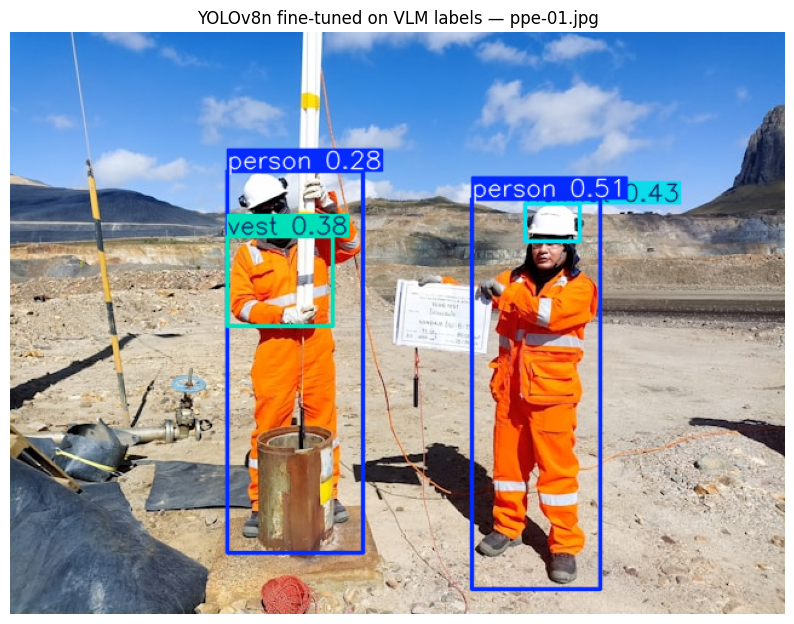

In [14]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt

sample_img = Path("samples/ppe-01.jpg")
pred = trained.predict(str(sample_img), imgsz=640, conf=0.25, save=False)[0]
annotated = Image.fromarray(pred.plot()[:, :, ::-1])
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"YOLOv8n fine-tuned on VLM labels — {sample_img.name}")
plt.show()

## Export to ONNX for OpenVINO serving

The cluster's serving stack has an OpenVINO Model Server (same one the Fraud Detection demo uses) that speaks KServe v2 and loads ONNX natively. Ultralytics ships an exporter, so this is a one-liner.

- `dynamic=True` → keep the batch dimension dynamic so OVMS can batch requests.
- `simplify=True` → fold constants, shrink the graph.
- `opset=13` → matches the OVMS runtime's `supportedModelFormats[onnx].version`.

In [ ]:
%%capture
!pip install onnx onnxslim onnxruntime

In [ ]:
onnx_path = Path(trained.export(
    format="onnx",
    imgsz=640,
    dynamic=True,
    simplify=True,
    opset=13,
))
print(f"Exported ONNX: {onnx_path}  ({onnx_path.stat().st_size / 1e6:.1f} MB)")

---

**Output:** `best.pt` + `best.onnx` under `runs/detect/ppe-vlm/weights/`.

**Next:** [05-register-and-deploy.ipynb](05-register-and-deploy.ipynb) — push `best.onnx` to S3, register it in the RHOAI Model Registry, and deploy it as a KServe `InferenceService` served by OpenVINO Model Server.